In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
tweets = []
labels = []

def load_tweets(filename, label):
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            tweets.append(line.rstrip())
            labels.append(label)

load_tweets('/content/drive/MyDrive/train_neg_full_cleaned.txt', 0)
load_tweets('/content/drive/MyDrive/train_pos_full_cleaned.txt', 1)

# Convert to NumPy array to facilitate indexing
tweets = np.array(tweets)
labels = np.array(labels)

print(f'{len(tweets)} tweets loaded')

2500000 tweets loaded


In [5]:
# Load the gloVe embedding
embeddings_index = {}
f = open('/content/drive/MyDrive/glove.twitter.27B.200d.txt')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' % len(embeddings_index))

Found 1193514 word vectors.


In [6]:
max_features = 20000

from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
train_tweets, val_tweets, train_labels, val_labels = train_test_split(tweets, labels, test_size=0.1, random_state=42)

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=max_features, filters='', split=' ', oov_token="<OOV>")

# Fit the tokenizer on the training tweets
tokenizer.fit_on_texts(train_tweets)

# Convert the training and validation tweets to sequences
train_sequences = tokenizer.texts_to_sequences(train_tweets)
val_sequences = tokenizer.texts_to_sequences(val_tweets)

Max tweet length: 72
Min tweet length: 1


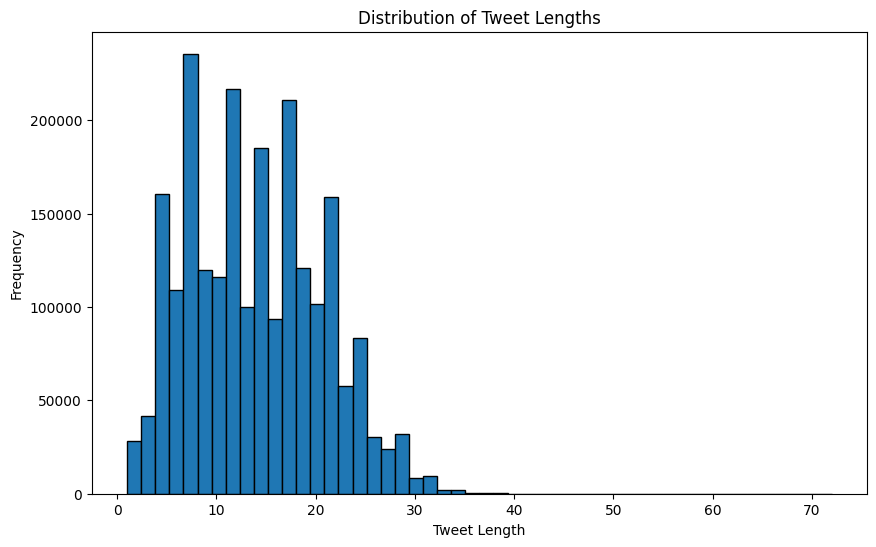

In [7]:
# Calculate the length of each tweet
tweet_lengths = np.array([len(tweet) for tweet in train_sequences])

# Calculate the max and min length of tweets
max_length = tweet_lengths.max()
min_length = tweet_lengths.min()

print(f'Max tweet length: {max_length}')
print(f'Min tweet length: {min_length}')

# Visualize the distribution of tweet lengths
plt.figure(figsize=(10, 6))
plt.hist(tweet_lengths, bins=50, edgecolor='black')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.show()


In [8]:
# Garbage collect data not used anymore to save memory
import gc
del train_tweets, val_tweets, tweets, labels
gc.collect()

6176

In [9]:
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

num_words = min(max_features, len(word_index)) + 1
print(num_words)

embedding_dim = 200
# First create a matrix of zeros, this is our embedding matrix
embedding_matrix = np.zeros((num_words, embedding_dim))

# For each word in out tokenizer lets try to find that word in the GloVe embedding
for word, i in word_index.items():
    if i > max_features:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # We found the word - add that words vector to the matrix
        embedding_matrix[i] = embedding_vector
    else:
        # Doesn't exist, assign a random vector
        embedding_matrix[i] = np.random.randn(embedding_dim)

Found 357231 unique tokens.
20001


In [10]:
# Garbage collect data not used anymore to save memory
del embeddings_index
gc.collect()

0

In [11]:
# From the above diagram, we see that most sentences are below 40 words
sequence_length = 40
# Pad the sequences
train_padded = pad_sequences(train_sequences, maxlen=sequence_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=sequence_length, padding='post', truncating='post')

In [12]:
# Garbage collect data not used anymore to save memory
del train_sequences, val_sequences
gc.collect()

0

In [13]:
# Print the word index, training sequences, and validation sequences
# Converting word index to a list of tuples to slice it
word_index_list = list(tokenizer.word_index.items())
print("Word Index:", word_index_list[:100])

# Print padded sequences if needed
print("Padded Training Sequences:", train_padded[:100])
print("Padded Validation Sequences:", val_padded[:100])

Word Index: [('<OOV>', 1), ('i', 2), ('!', 3), ('to', 4), ('the', 5), ('you', 6), ('a', 7), ('sad_emoji', 8), ('is', 9), ('and', 10), ('it', 11), ('my', 12), ('of', 13), ('not', 14), ('me', 15), ('?', 16), ('for', 17), ('in', 18), ('``', 19), ('that', 20), ('-', 21), ('this', 22), ('have', 23), ('am', 24), ('on', 25), ('with', 26), ('so', 27), ('do', 28), ('be', 29), ('are', 30), ('happy_emoji', 31), (':', 32), ('your', 33), ('but', 34), ('will', 35), ('just', 36), ('can', 37), ('rt', 38), ('kiss_emoji', 39), ('wa', 40), ('/', 41), ('love', 42), ('like', 43), ('all', 44), ('at', 45), ('get', 46), ('want', 47), ('we', 48), ('know', 49), ('frame', 50), ('up', 51), ("'s", 52), ('one', 53), ('day', 54), ('lol', 55), ('good', 56), ('what', 57), ('go', 58), ('when', 59), ('now', 60), ('follow', 61), ('if', 62), ('going', 63), ('no', 64), ('out', 65), ('please', 66), ("'", 67), ('too', 68), ('from', 69), ('he', 70), ('got', 71), ('time', 72), ('see', 73), ('thanks', 74), ('back', 75), ('how',

In [14]:
# Garbage collect data not used anymore to save memory
del tokenizer
gc.collect()

0

## two layers BiLSTM


In [20]:
from keras.initializers import Constant
from keras.models import Model
from keras.layers import *

inputs = Input(shape=(sequence_length,), dtype='int32')
embedding_layer = Embedding(num_words, embedding_dim, embeddings_initializer=Constant(embedding_matrix), input_length=sequence_length, trainable=True)(inputs)

# two bilstm layers (tested different LSTM units)
x = Bidirectional(LSTM(512, dropout = 0.2, recurrent_dropout = 0.2, return_sequences = True))(embedding_layer)
x = Dropout(0.2)(x)

x = Bidirectional(LSTM(512, dropout = 0.2, recurrent_dropout = 0.2))(x)
x = Dropout(0.2)(x)

# two dense layers (also tested with only one or three dense layers)
x = Dense(32, activation = "relu")(x)
x = Dropout(0.2)(x)
x = Dense(16, activation = "relu")(x)

output = Dense(units=1, activation='sigmoid')(x)

In [21]:
model = Model(inputs=inputs, outputs=output)

# note we're using binary_crossentropy here instead of categorical
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 40)]              0         
                                                                 
 embedding_2 (Embedding)     (None, 40, 200)           4000200   
                                                                 
 bidirectional_3 (Bidirecti  (None, 40, 1024)          2920448   
 onal)                                                           
                                                                 
 dropout_4 (Dropout)         (None, 40, 1024)          0         
                                                                 
 bidirectional_4 (Bidirecti  (None, 1024)              6295552   
 onal)                                                           
                                                                 
 dropout_5 (Dropout)         (None, 1024)              0   

In [ ]:
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
# Check for GPU availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Load the parameters from previous epochs to train further
#checkpoint_path = '/content/drive/MyDrive/BiLSTM/cp-0002.ckpt'
#model.load_weights(checkpoint_path)

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/BiLSTM/cp-{epoch:04d}.ckpt"',  # File path format to save the model
    save_freq='epoch',                      # Save the model after every epoch
    save_weights_only=True,                # Save the entire model (set to True to save only weights)
    verbose=1                               # Verbosity mode, 1 = show messages
)

batch_size = 256
history = model.fit(train_padded, train_labels, epochs=30, callbacks=[checkpoint], batch_size=batch_size, verbose=1, validation_data=(val_padded, val_labels))